In [23]:
import numpy as np

from lo_tools import zfun
import gfun_utility as gfu

# ae0 analytical model estuary
# copied from LO/user/gfun_user.py 

# define grid coordinates
lon_list = [-2, 0, 1, 2]
x_res_list = [2500, 500, 500, 2500]

lat_list = [43, 44.9, 45.1, 47]
y_res_list = [2500, 500, 500, 2500]

Lon_vec, Lat_vec = gfu.stretched_grid(
    lon_list, x_res_list,
    lat_list, y_res_list)
lon, lat = np.meshgrid(Lon_vec, Lat_vec)

# make bathymetry by hand
z = np.zeros(lon.shape)
x, y = zfun.ll2xy(lon, lat, 0, 45) # convert to meter resolution
zshelf = x * 1e-3 
zestuary = -20 + 20*x/1e5 + 20/(1e4)*np.abs(y)
z = zshelf
mask = zestuary < z # land mask (where estuary shallower than shelf)
z[mask] = zestuary[mask]

# make masked array for plotting 
# set land points to nan
zm = z.copy()
zm[zm >= 0] = np.nan

In [32]:
# station coordinates
# copied from job_lists.py
stations = {
#    'boundary': (-2, 45),
    'Ocean': (-1, 45),
    'Estuary Mouth': (0, 45),
    'Estuary Middle': (0.5, 45),
    'Estuary End': (1.1, 45)
}

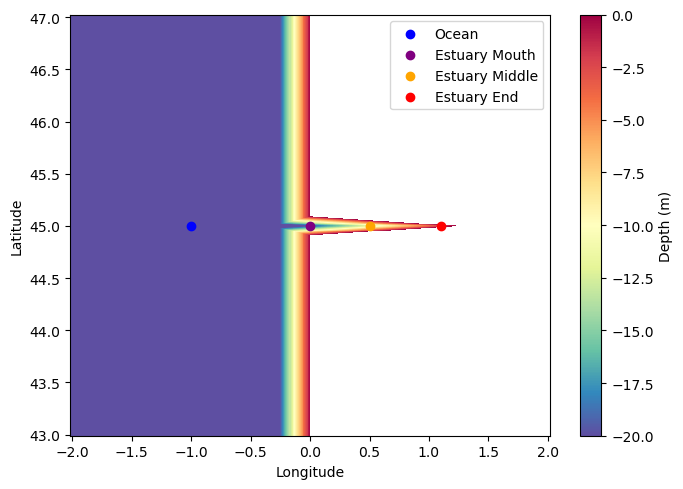

In [36]:
import matplotlib.pyplot as plt
%matplotlib inline

station_colors = {
    'Ocean': 'blue',
    'Estuary Mouth': 'purple',
    'Estuary Middle': 'orange',
    'Estuary End': 'red'
}

fig, ax = plt.subplots(figsize=(7,5))

# plot bathymetry in lon/lat coordinates
cs = ax.pcolormesh(lon, lat, zm, vmin=-20, vmax=0, cmap='Spectral_r', shading='auto')

# colorbar
cbar = fig.colorbar(cs, ax=ax)
cbar.set_label('Depth (m)')

# plot station points
for name, (xs, ys) in stations.items():
    ax.scatter(xs, ys, color=station_colors[name],label=name)

# legend for stations
ax.legend(title="", loc='upper right')

ax.set_title("")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")

plt.tight_layout()
plt.show()